# Environment

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import os
from pathlib import Path
from glob import glob
os.chdir('/Users/burkelawlor/Repos/hci-Xenium')

import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad

from utils.data_loading import *
from utils.diffex import *

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load data

In [23]:
adata_masto = ad.read_h5ad("./data/processed/adata/masto_2_annotated.h5ad")
adata_immune = adata_masto[adata_masto.obs['ct_immune'].notna()].copy()

immune_cts = adata_immune.obs['ct_immune'].unique().to_list()
immune_cts.sort()

non_immune_cts = [x for x in adata_masto.obs['ct_detailed'].unique().to_list() if x not in immune_cts]
non_immune_cts.sort()

combos = [('MAST','NL')]

out_dir = 'masto-analysis'

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Bulk

In [12]:
adata = adata_masto.copy()

sample_col = 'sample_name'
celltype_col = None
condition = 'sample_set'


analyses_dict = {}
all_diffex_results = []
all_sig_by_gene_results = []
all_sig_by_ct_results = []

for comparison in combos:
    print(comparison)
    
    # Run differential expression analysis
    contrast = (condition, comparison[0], comparison[1])
    adata_subset = adata[adata.obs[condition].isin(comparison)].copy()
    analysis = DiffExAnalysis(adata_subset, sample_col=sample_col, celltype_col=celltype_col, condition_col=condition, contrast=contrast)
    results_df = analysis.run()
    analyses_dict[comparison] = analysis

    # Save results
    results_df['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_diffex_results.append(results_df)

    # Summarize results by gene
    sig_by_gene = analysis.summarize_sig_by_gene()
    sig_by_gene_immune = analysis.summarize_sig_by_gene(subset_cts=immune_cts)
    sig_by_gene = pd.merge(sig_by_gene, sig_by_gene_immune, left_index=True, right_index=True, suffixes=('','_immune')).reset_index()
    sig_by_gene['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_gene_results.append(sig_by_gene)

    # Summarize results by cell type
    sig_by_ct = results_df.groupby('ct').agg({'sig': 'sum'}).sort_values('sig', ascending=False).reset_index()
    sig_by_ct['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_ct_results.append(sig_by_ct)


    # GSEA 
    gsea_results_df = run_gsea(results_df, outdir=f"output/{out_dir}/gsea_prerank_output/bulk/{'-'.join(comparison)}")


# Concatenate results
all_diffex_results_df = pd.concat(all_diffex_results, ignore_index=True)
all_sig_by_gene_df = pd.concat(all_sig_by_gene_results, ignore_index=True)
all_sig_by_ct_df = pd.concat(all_sig_by_ct_results, ignore_index=True)
all_sig_by_ct_df = all_sig_by_ct_df.pivot(columns='comparison', index='ct', values='sig')


# Write out
prefix = 'bulk'
all_diffex_results_df.to_csv(f'./output/{out_dir}/diffex/{prefix}_diffex_results.csv', index=False)
all_sig_by_gene_df.to_csv(f'./output/{out_dir}/{prefix}_summary_by_gene.csv', index=False)
all_sig_by_ct_df.to_csv(f'./output/{out_dir}/{prefix}_summary_by_ct.csv')


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


('MAST', 'NL')


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.15 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

2026-07-02 17:16:56,061 [INFO] Parsing data files for GSEA.............................
2026-07-02 17:16:56,063 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-07-02 17:16:56,067 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-07-02 17:16:56,067 [INFO] 0050 gene_sets used for further statistical testing.....
2026-07-02 17:16:56,068 [INFO] Start to run GSEA...Might take a while..................


Log2 fold change & Wald test p-value: sample_set MAST vs NL
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1    2931.625281       -0.066438  0.594386 -0.111776  0.911001  0.971279
AAMP     2623.261572        0.133675  0.132838  1.006297  0.314273  0.677009
AAR2      723.545052        0.357943  0.130553  2.741756  0.006111  0.131255
AARSD1    656.474775       -0.011121  0.130378 -0.085295  0.932027  0.975968
ABAT      216.929655       -0.046342  0.215547 -0.214998  0.829769  0.941525
...              ...             ...       ...       ...       ...       ...
ZSCAN26   554.090541       -0.251814  0.200306 -1.257146  0.208701  0.582499
ZSWIM6    298.720263        0.020543  0.291998  0.070353  0.943913  0.979115
ZUP1      641.961102       -0.036009  0.143164 -0.251523  0.801410  0.932125
ZYG11B    866.846619       -0.096485  0.092646 -1.041442  0.297670  0.662190
ZYX      3156.747317        0.182914  0.299716  0.610292  0.541669  0.825525

[5001 rows x 6 

2026-07-02 17:16:59,197 [INFO] Congratulations. GSEApy runs successfully................



       Name                           Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
0   prerank      Interferon Gamma Response  0.688211  2.508057   0.001000   0.001000       0.001  65/106  22.21%  NFKB1;IRF4;SLAMF7;STAT1;RSAD2;STAT3;MYD88;IFIT...
10  prerank      Unfolded Protein Response  0.639944  1.863964   0.001000   0.001000       0.007   19/34  20.14%  EIF4A3;YWHAZ;DKC1;TUBB2A;EIF4A1;KIF5B;NOLC1;BA...
8   prerank               mTORC1 Signaling   0.53992  1.916733   0.001000   0.001000       0.005   36/92  18.39%  GMPS;SDF2L1;TES;TBK1;RRM2;CCT6A;GLA;HSPA4;MCM2...
7   prerank                G2-M Checkpoint  0.525923  1.936199   0.001000   0.001000       0.004  65/116  24.60%  MAD2L1;DKC1;CTCF;TOP1;SYNCRIP;MCM6;KATNA1;MYBL...
6   prerank       IL-6/JAK/STAT3 Signaling  0.627298   2.12544   0.001000   0.001000       0.001   26/69  13.51%  STAT1;STAT3;IL2RG;MYD88;CSF2RA;PTPN11;GRB2;IL4...
9   prerank  TNF

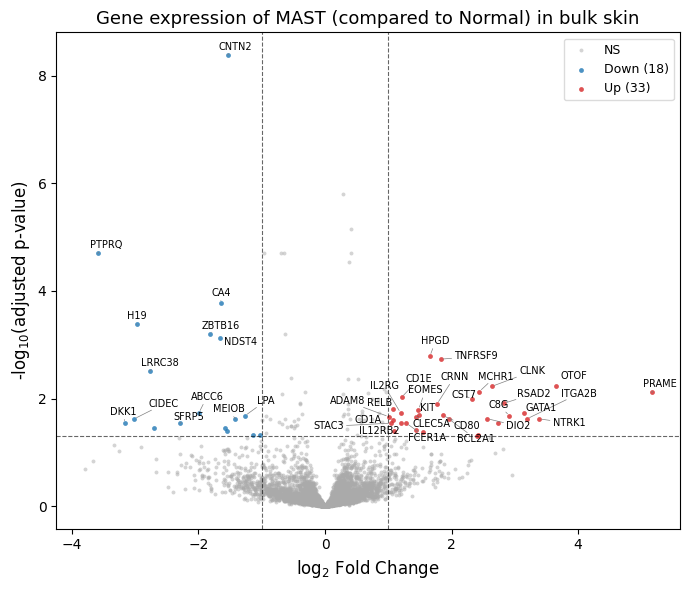

In [14]:
all_diffex_results_df = pd.read_csv(f'./output/{out_dir}/diffex/bulk_diffex_results.csv')

comparison = 'MAST vs NL'

df = all_diffex_results_df[all_diffex_results_df['comparison'] == comparison]

plot_volcano(df, f'Gene expression of MAST (compared to Normal) in bulk skin', top_n_labels=40)
plt.show()

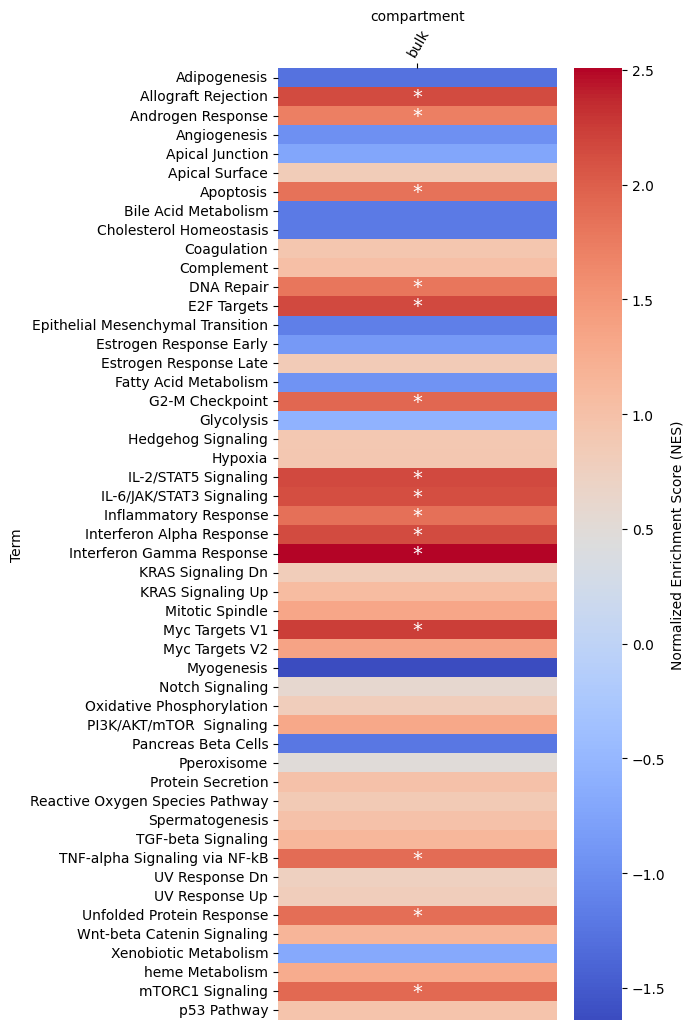

In [16]:
f = f'./output/{out_dir}/gsea_prerank_output/bulk/MAST-NL/gseapy.gene_set.prerank.report.csv'

gsea_result = pd.read_csv(f)
gsea_result['compartment'] = 'bulk'
plot_gsea_heatmap(gsea_result, 'compartment')

# Immune

In [17]:
adata = adata_immune.copy()

sample_col = 'sample_name'
celltype_col = None
condition = 'sample_set'


analyses_dict = {}
all_diffex_results = []
all_sig_by_gene_results = []
all_sig_by_ct_results = []

for comparison in combos:
    print(comparison)
    
    # Run differential expression analysis
    contrast = (condition, comparison[0], comparison[1])
    adata_subset = adata[adata.obs[condition].isin(comparison)].copy()
    analysis = DiffExAnalysis(adata_subset, sample_col=sample_col, celltype_col=celltype_col, condition_col=condition, contrast=contrast)
    results_df = analysis.run()
    analyses_dict[comparison] = analysis

    # Save results
    results_df['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_diffex_results.append(results_df)

    # Summarize results by gene
    sig_by_gene = analysis.summarize_sig_by_gene()
    sig_by_gene_immune = analysis.summarize_sig_by_gene(subset_cts=immune_cts)
    sig_by_gene = pd.merge(sig_by_gene, sig_by_gene_immune, left_index=True, right_index=True, suffixes=('','_immune')).reset_index()
    sig_by_gene['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_gene_results.append(sig_by_gene)

    # Summarize results by cell type
    sig_by_ct = results_df.groupby('ct').agg({'sig': 'sum'}).sort_values('sig', ascending=False).reset_index()
    sig_by_ct['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_ct_results.append(sig_by_ct)


    # GSEA 
    gsea_results_df = run_gsea(results_df, outdir=f"output/{out_dir}/gsea_prerank_output/immune/{'-'.join(comparison)}")


# Concatenate results
all_diffex_results_df = pd.concat(all_diffex_results, ignore_index=True)
all_sig_by_gene_df = pd.concat(all_sig_by_gene_results, ignore_index=True)
all_sig_by_ct_df = pd.concat(all_sig_by_ct_results, ignore_index=True)
all_sig_by_ct_df = all_sig_by_ct_df.pivot(columns='comparison', index='ct', values='sig')


# Write out
prefix = 'immune'
all_diffex_results_df.to_csv(f'./output/{out_dir}/diffex/{prefix}_diffex_results.csv', index=False)
all_sig_by_gene_df.to_csv(f'./output/{out_dir}/{prefix}_summary_by_gene.csv', index=False)
all_sig_by_ct_df.to_csv(f'./output/{out_dir}/{prefix}_summary_by_ct.csv')

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Fitting size factors...
... done in 0.00 seconds.



('MAST', 'NL')
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.15 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

2026-07-02 17:18:42,849 [WARNING] Duplicated values found in preranked stats: 2.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-02 17:18:42,849 [INFO] Parsing data files for GSEA.............................
2026-07-02 17:18:42,851 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-07-02 17:18:42,854 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-07-02 17:18:42,855 [INFO] 0050 gene_sets used for further statistical testing.....
2026-07-02 17:18:42,855 [INFO] Start to run GSEA...Might take a while.....

Log2 fold change & Wald test p-value: sample_set MAST vs NL
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1     16.839321        0.141101  1.056052  0.133612  0.893710  0.989258
AAMP     174.989584        0.011762  0.178634  0.065844  0.947502  0.994995
AAR2      61.143296        0.381143  0.237864  1.602358  0.109076  0.616753
AARSD1    52.670372        0.062510  0.230966  0.270645  0.786664  0.977801
ABAT      38.621041       -0.131932  0.270238 -0.488207  0.625403  0.949640
...             ...             ...       ...       ...       ...       ...
ZSCAN26   71.570775       -0.349583  0.265876 -1.314837  0.188565  0.737585
ZSWIM6    49.103877       -0.521818  0.351139 -1.486074  0.137259  0.655525
ZUP1      68.717284        0.056270  0.303881  0.185172  0.853094  0.983291
ZYG11B    70.862910       -0.126265  0.243356 -0.518849  0.603866  0.941142
ZYX      586.094037       -0.115853  0.162469 -0.713079  0.475797  0.889189

[5001 rows x 6 columns]
[OK

2026-07-02 17:18:45,308 [INFO] Congratulations. GSEApy runs successfully................



       Name                               Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
0   prerank          Interferon Alpha Response  0.776218  2.299197   0.001000   0.001000       0.001   22/44  12.29%  IFIT3;IFI44L;RSAD2;IFITM1;TRAFD1;IFI35;MX1;CNP...
1   prerank          Interferon Gamma Response  0.676665  2.296277   0.001000   0.001000       0.001  44/106  12.78%  IFIT3;STAT3;STAT1;IFI44L;RSAD2;IFIT1;CSF2RB;TR...
2   prerank          Unfolded Protein Response  0.725321  2.015636   0.001000   0.001000       0.001   16/34  11.11%  IFIT1;STC2;SLC7A5;ERN1;SHC1;YWHAZ;HSPA9;VEGFA;...
3   prerank      TNF-alpha Signaling via NF-kB  0.530412  1.780442   0.001000   0.006010       0.018  38/110  16.54%  TNC;CD80;GADD45A;SLC2A3;RELB;RELA;ACKR3;TNFRSF...
5   prerank               IL-2/STAT5 Signaling  0.500338  1.737784   0.001000   0.009794       0.043  42/123  15.71%  CKAP4;CST7;SOCS2;GATA1;SOCS1;PIM1;MUC1;TNF

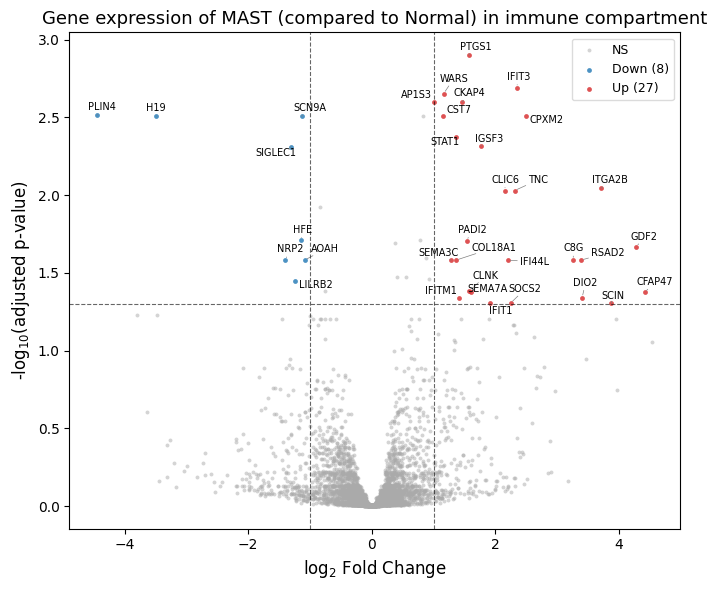

In [60]:
all_diffex_results_df = pd.read_csv(f'./output/{out_dir}/diffex/immune_diffex_results.csv')

comparison = 'MAST vs NL'

df = all_diffex_results_df[all_diffex_results_df['comparison'] == comparison]
plot_volcano(df, f'Gene expression of MAST (compared to Normal) in immune compartment', top_n_labels=40)
plt.show()

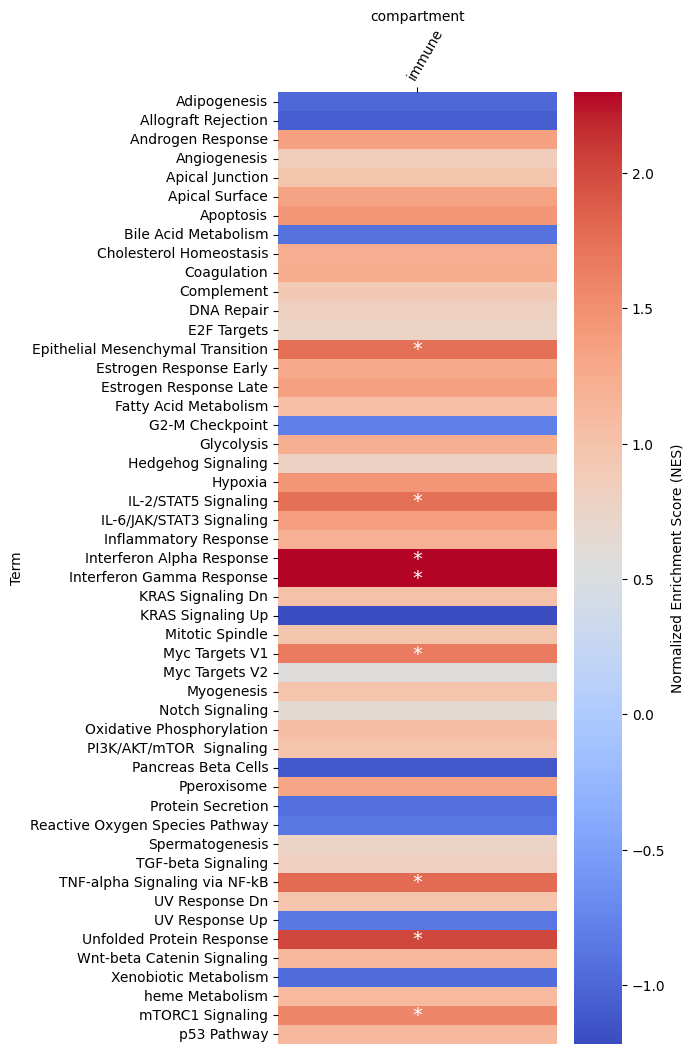

In [20]:
f = f'./output/{out_dir}/gsea_prerank_output/immune/MAST-NL/gseapy.gene_set.prerank.report.csv'

gsea_result = pd.read_csv(f)
gsea_result['compartment'] = 'immune'
plot_gsea_heatmap(gsea_result, 'compartment')

# All cell types

In [21]:
adata = adata_masto.copy()

sample_col = 'sample_name'
celltype_col = 'ct_detailed'
condition = 'sample_set'


analyses_dict = {}
all_diffex_results = []
all_sig_by_gene_results = []
all_sig_by_ct_results = []

for comparison in combos:
    print(comparison)
    
    # Run differential expression analysis
    contrast = (condition, comparison[0], comparison[1])
    adata_subset = adata[adata.obs[condition].isin(comparison)].copy()
    analysis = DiffExAnalysis(adata_subset, sample_col=sample_col, celltype_col=celltype_col, condition_col=condition, contrast=contrast)
    results_df = analysis.run()
    analyses_dict[comparison] = analysis

    # Save results
    results_df['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_diffex_results.append(results_df)

    # Summarize results by gene
    sig_by_gene = analysis.summarize_sig_by_gene()
    sig_by_gene_immune = analysis.summarize_sig_by_gene(subset_cts=immune_cts)
    sig_by_gene = pd.merge(sig_by_gene, sig_by_gene_immune, left_index=True, right_index=True, suffixes=('','_immune')).reset_index()
    sig_by_gene['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_gene_results.append(sig_by_gene)

    # Summarize results by cell type
    sig_by_ct = results_df.groupby('ct').agg({'sig': 'sum'}).sort_values('sig', ascending=False).reset_index()
    sig_by_ct['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_ct_results.append(sig_by_ct)


    # GSEA -- we're writing these out here
    for ct in results_df.ct.unique():
        print(ct)
        ct_result = results_df[results_df.ct == ct].copy()
        gsea_results_df = run_gsea(ct_result, outdir=f"output/{out_dir}/gsea_prerank_output/{ct}/{'-'.join(comparison)}")


all_diffex_results_df = pd.concat(all_diffex_results, ignore_index=True)
all_diffex_results_df.to_csv(f'./output/{out_dir}/diffex/by_ct_diffex_results.csv', index=False)

all_sig_by_gene_df = pd.concat(all_sig_by_gene_results, ignore_index=True)
all_sig_by_gene_df.to_csv(f'./output/{out_dir}/diffex/by_ct_diffex_summary_by_gene.csv', index=False)

all_sig_by_ct_df = pd.concat(all_sig_by_ct_results, ignore_index=True)
all_sig_by_ct_df = all_sig_by_ct_df.pivot(columns='comparison', index='ct', values='sig')
all_sig_by_ct_df.to_csv(f'./output/{out_dir}/diffex/by_ct_diffex_summary_by_ct.csv')


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


('MAST', 'NL')


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[SKIP] Adipocytes: only 3 pseudobulk samples (need 4)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.14 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


...

       Name                               Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
0   prerank                        Coagulation  0.577437  1.856481   0.001675   0.016444       0.011   15/40  18.62%  CTSK;FYN;MMP14;LAMP2;CFH;ADAM9;COMP;THBD;PROS1...
1   prerank  Epithelial Mesenchymal Transition   0.46925  1.676641   0.001000   0.062785       0.081   27/79  21.22%  CD59;THY1;MMP14;ABI3BP;FMOD;COMP;COL5A2;TNC;NO...
2   prerank      TNF-alpha Signaling via NF-kB  0.442222  1.635598   0.001529   0.074245       0.138   27/93  14.45%  CSF1;EGR3;CDKN1A;ICAM1;NFKB2;TNF;TNC;CD83;TNFR...
8   prerank          Interferon Gamma Response  0.373797  1.397879   0.025915   0.233366       0.724   25/99  14.34%  CDKN1A;TRAFD1;HERC6;CFH;ICAM1;OAS3;IFI35;NOD1;...
6   prerank                         Complement   0.39759  1.428117   0.026521   0.235335       0.651   24/82  20.09%  CD59;FYN;CTSC;ANXA5;MMP14;FDX1;LAMP2;CFH;A

2026-07-02 17:21:18,991 [INFO] Congratulations. GSEApy runs successfully................

2026-07-02 17:21:18,999 [WARNING] Duplicated values found in preranked stats: 10.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-02 17:21:19,000 [INFO] Parsing data files for GSEA.............................
2026-07-02 17:21:19,002 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-07-02 17:21:19,005 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-07-02 17:21:19,005 [INFO] 0050 gene_sets used for further statistical testing.....
2026-07-02 17:21:19,006 [INFO] Start to run GSEA...Might take a while..................


       Name                           Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
0   prerank      Interferon Gamma Response  0.594397  2.166995   0.001000   0.001000       0.001  44/106  15.29%  CIITA;IL10RA;IRF8;CASP1;STAT1;PTPN6;CASP3;IRF4...
1   prerank            Allograft Rejection  0.563022  2.140807   0.001000   0.001000       0.001  53/132  17.23%  EIF3A;IRF8;SPI1;IL18;CD4;STAT1;FCGR2B;STAB1;CC...
2   prerank              Androgen Response  0.587363  1.816769   0.001000   0.010333       0.023   11/41   9.27%  SGK1;CCND1;IQGAP2;HPGD;MAP7;INPP4B;NDRG1;PTK2B...
4   prerank           IL-2/STAT5 Signaling   0.47256  1.756137   0.001000   0.011321       0.042  40/123  15.19%  IL10RA;IRF8;IL18R1;RHOH;TNFRSF18;CASP3;IRF4;HO...
3   prerank               mTORC1 Signaling   0.48497  1.767226   0.002088   0.012467       0.037   37/91  21.37%  TES;SYTL2;SLC2A1;CTSC;SQLE;ATP2A2;ACLY;ITGB2;C...
5   prerank     

2026-07-02 17:21:21,304 [INFO] Congratulations. GSEApy runs successfully................



       Name                               Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
1   prerank          Unfolded Protein Response  0.697903  1.852274   0.001000   0.012677       0.019   16/34  12.14%  TUBB2A;BAG3;KIF5B;HSPA9;YWHAZ;EIF4G1;STC2;ATF6...
0   prerank                     Myc Targets V1  0.613104  1.894256   0.001000   0.017348       0.013   32/79  15.68%  XRCC6;PCNA;MCM6;YWHAQ;SYNCRIP;C1QBP;MCM4;CCT5;...
2   prerank                        E2F Targets  0.550795  1.782229   0.001000   0.019127       0.041  45/111  19.89%  XRCC6;RFC3;PCNA;MCM6;SYNCRIP;SNRPB;MCM4;CDKN3;...
4   prerank  Epithelial Mesenchymal Transition  0.534556   1.70561   0.001000   0.022419       0.077  30/100  12.10%  CCN2;CTHRC1;GJA1;THY1;POSTN;COL4A2;THBS1;LOXL2...
3   prerank                Allograft Rejection  0.513231  1.708711   0.001587   0.026022       0.072  33/131  13.17%  CCL19;CD4;THY1;CCL13;SPI1;IL4R;PTPN6;HIF1A

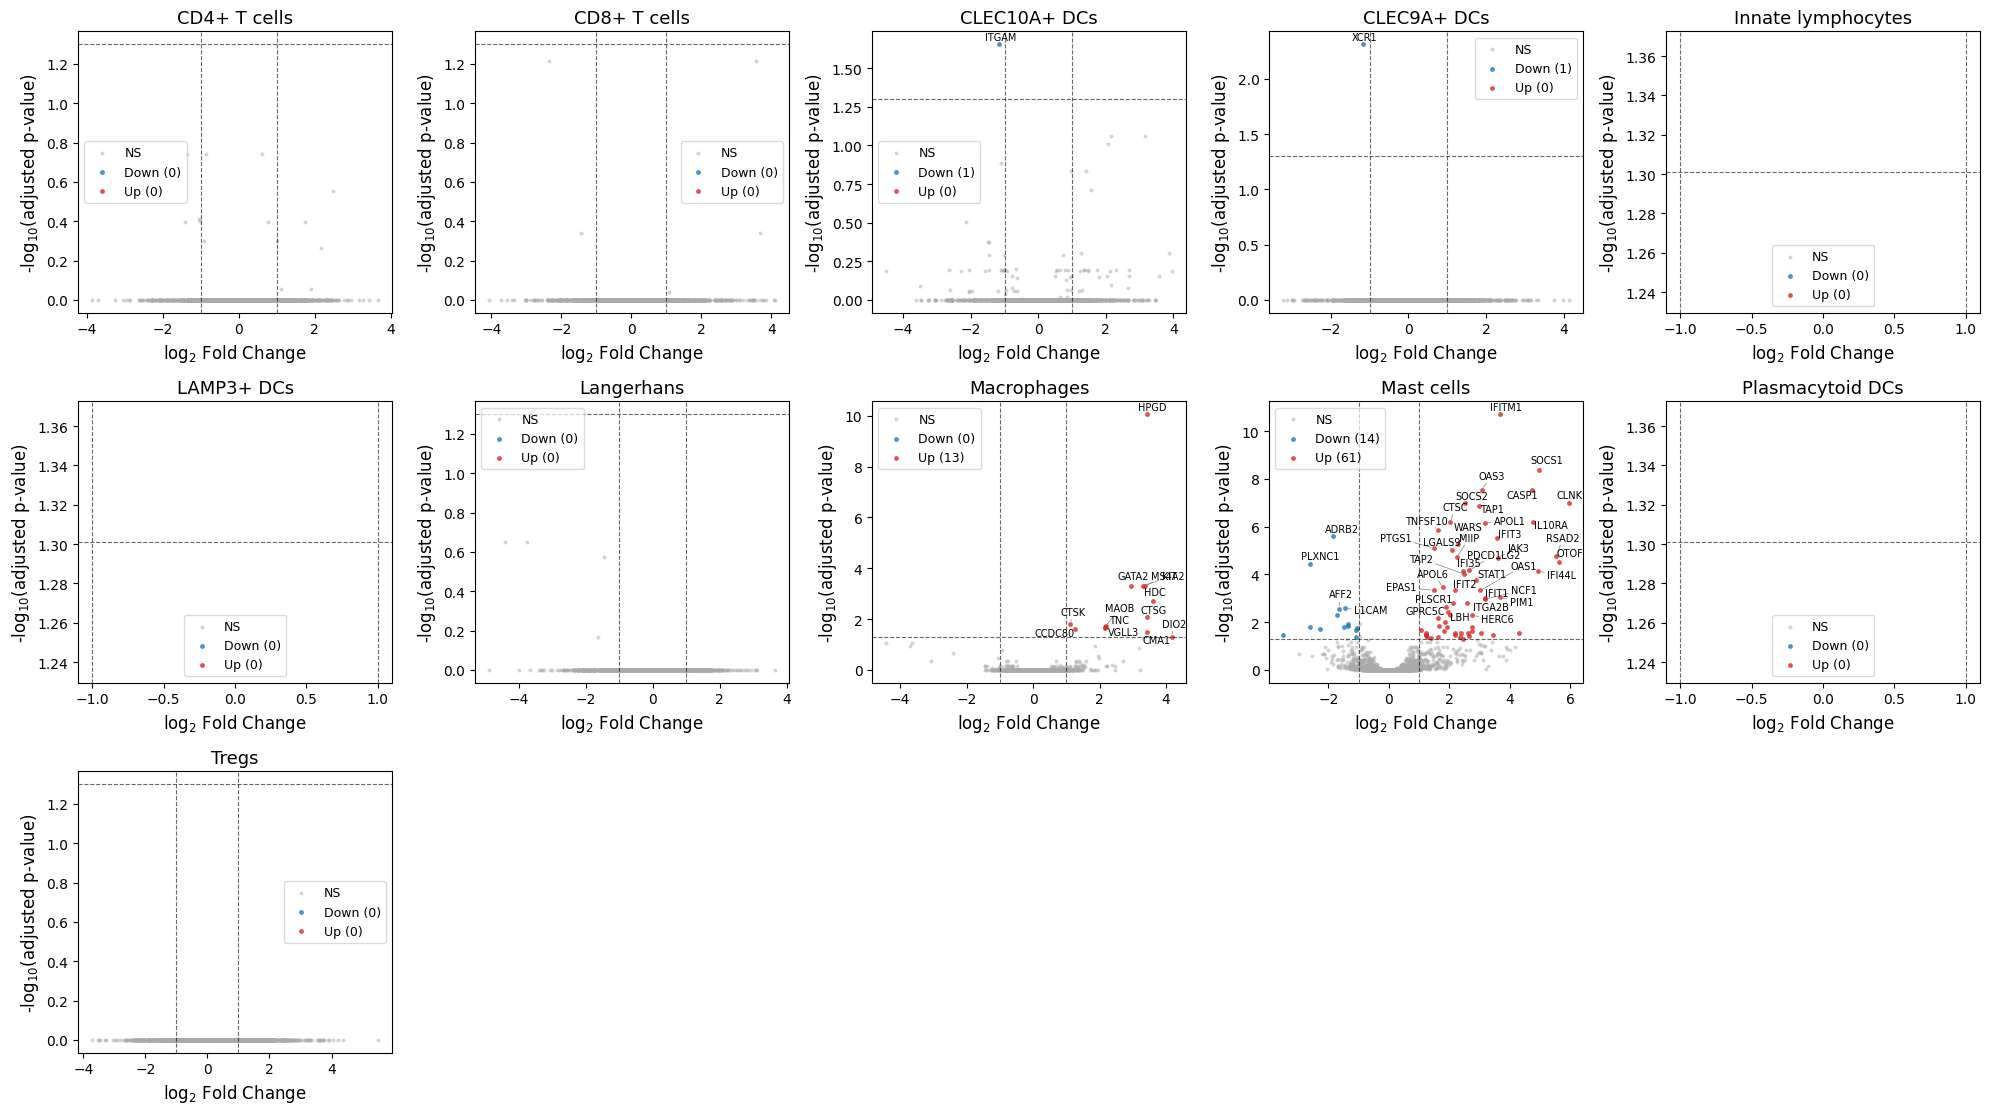

In [66]:
all_diffex_results_df = pd.read_csv(f'./output/{out_dir}/diffex/by_ct_diffex_results.csv')
comparison = 'MAST vs NL'
groups = immune_cts

ncols = 5
nrows = math.ceil(len(groups) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.75))
axes = axes.flatten()

for i, ct in enumerate(groups):
    df = all_diffex_results_df[
        (all_diffex_results_df['comparison'] == comparison) &
        (all_diffex_results_df['ct'] == ct)
    ]
    plot_volcano(df, f'{ct}', top_n_labels=40, ax=axes[i])

for ax in axes[len(groups):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

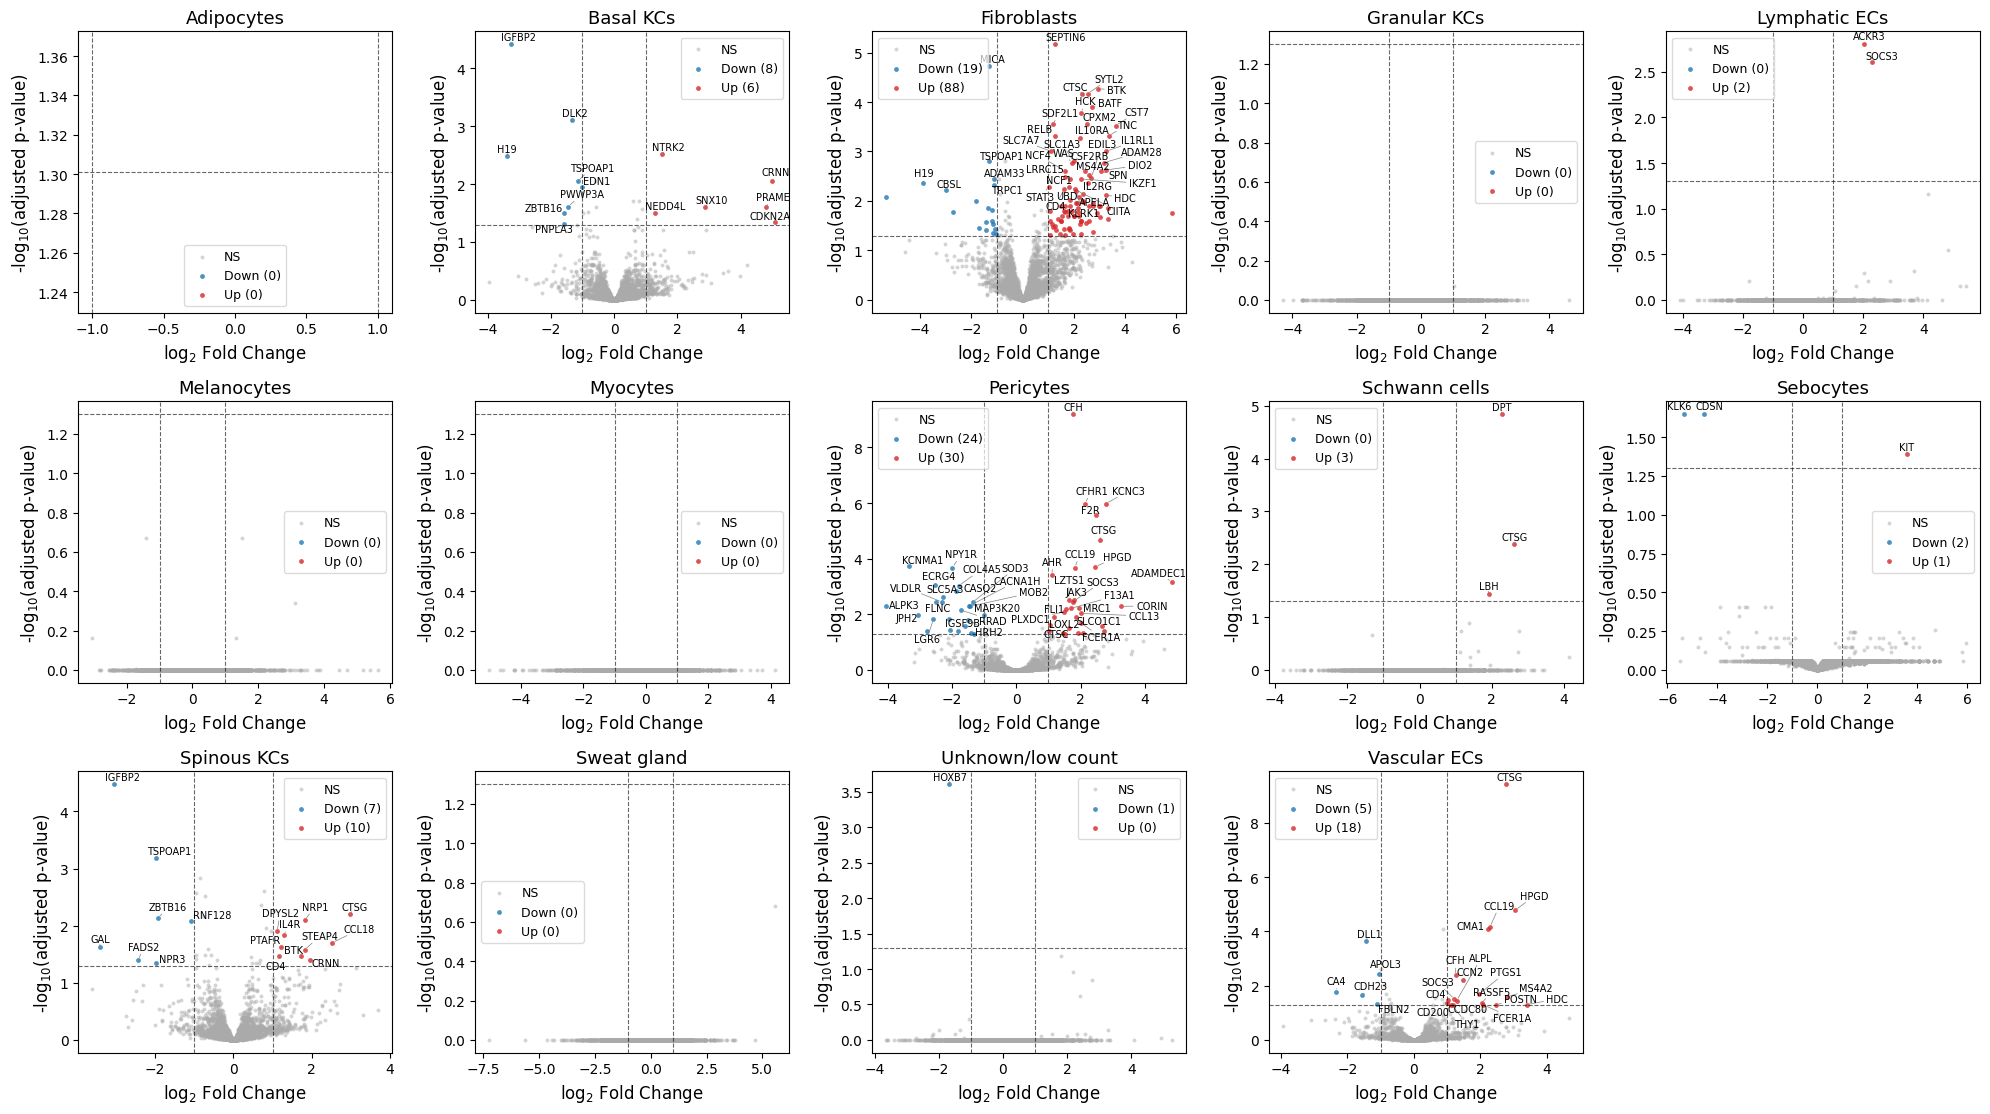

In [69]:
all_diffex_results_df = pd.read_csv(f'./output/{out_dir}/diffex/by_ct_diffex_results.csv')
comparison = 'MAST vs NL'
groups = non_immune_cts

ncols = 5
nrows = math.ceil(len(groups) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.75))
axes = axes.flatten()

for i, ct in enumerate(groups):
    df = all_diffex_results_df[
        (all_diffex_results_df['comparison'] == comparison) &
        (all_diffex_results_df['ct'] == ct)
    ]
    plot_volcano(df, f'{ct}', top_n_labels=40, ax=axes[i])

for ax in axes[len(groups):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/l8/r_bqmkfd36n6y9mvy600d2580000gn/T/ipykernel_35977/2010660473.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


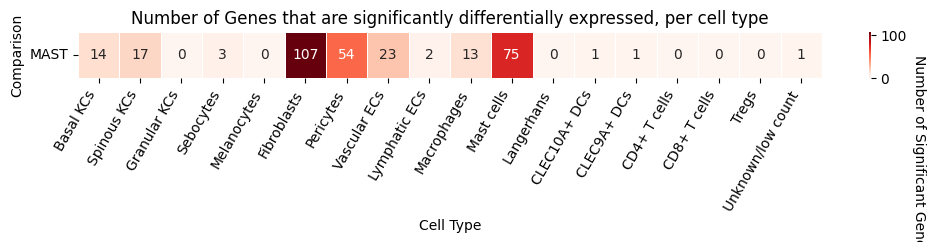

In [59]:
df_for_heatmap = pd.read_csv(f'./output/{out_dir}/diffex/by_ct_diffex_summary_by_ct.csv')
df_for_heatmap = df_for_heatmap.set_index('ct')

order =[
    'Basal KCs', 'Spinous KCs', 'Granular KCs', 'Sebocytes',
    'Melanocytes',
    'Fibroblasts', 'Pericytes',
    'Vascular ECs', 'Lymphatic ECs',
    'Macrophages', 'Mast cells', 'Langerhans', 'CLEC10A+ DCs', 'CLEC9A+ DCs', 
    'CD4+ T cells', 'CD8+ T cells', 'Tregs',
    'Unknown/low count',
]

df_for_heatmap = df_for_heatmap.loc[order]

comparison_map = {
    'MAST vs NL':'MAST',
}

col_order = comparison_map.values()#['LP', 'OLP', 'LPP', 'ICI LP', 'OLP▵', 'LPP▵', 'ICI LP▵']
df_for_heatmap.columns = df_for_heatmap.columns.map(comparison_map)
df_for_heatmap = df_for_heatmap[col_order].T

plt.figure(figsize=(12, 0.6))
sns.heatmap(df_for_heatmap, annot=True, fmt=".0f", cmap='Reds', linewidths=0.5) 
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.title('Number of Genes that are significantly differentially expressed, per cell type')
plt.ylabel('Comparison')
plt.xlabel('Cell Type')

cbar = plt.gca().collections[0].colorbar
cbar.set_label('Number of Significant Genes', rotation=270, ha='left', va='bottom')
plt.tight_layout()
plt.show()

# GSEA heatmap 

In [34]:
f_pattern = f'./output/{out_dir}/gsea_prerank_output/*/MAST-NL/gseapy.gene_set.prerank.report.csv'
files = glob(f_pattern)

gsea_full_results = []
for f in files:
    df = pd.read_csv(f)
    
    ct = f.split('/')[-3]
    df.insert(0, 'ct', ct)
    
    gsea_full_results.append(df)

gsea_full_results_df = pd.concat(gsea_full_results, ignore_index=True)

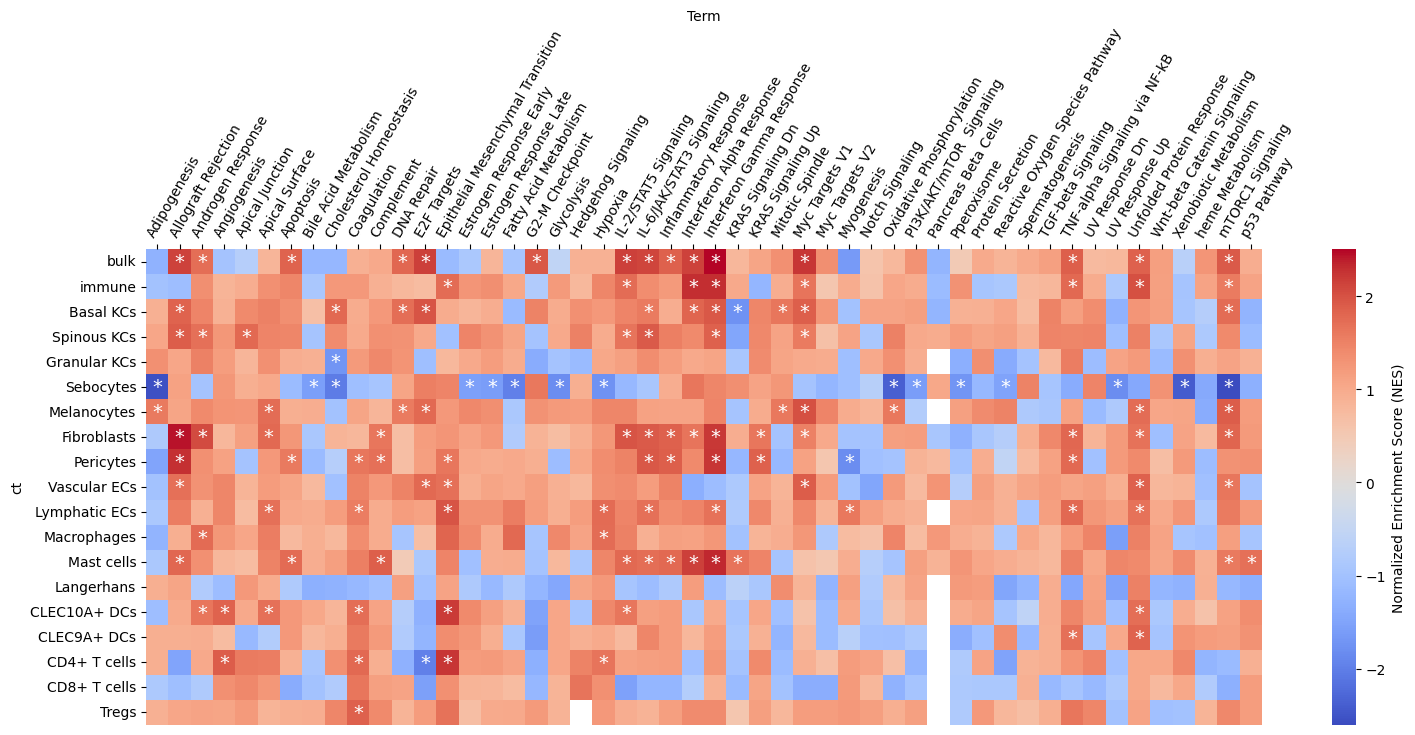

In [37]:
order = [
    'bulk',
    'immune',
    'Basal KCs', 'Spinous KCs', 'Granular KCs', 'Sebocytes',
    'Melanocytes',
    'Fibroblasts', 'Pericytes',
    'Vascular ECs', 'Lymphatic ECs',
    'Macrophages', 'Mast cells', 'Langerhans', 'CLEC10A+ DCs', 'CLEC9A+ DCs', 
    'CD4+ T cells', 'CD8+ T cells', 'Tregs', 
]

plot_gsea_heatmap(gsea_full_results_df, 'ct', order=order, transpose=True, figsize=(7,18))